## Step 1: Import Required Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##Step 2: Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('/content/uber.csv')

## Step 3: View Dataset

In [3]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1.0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1.0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1.0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3.0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5.0


In [4]:
df.tail()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
89348,16872002,2014-06-06 13:24:33.0000001,14.5,2014-06-06 13:24:33 UTC,-73.973738,40.764828,-73.989990,40.739271,1.0
89349,47140178,2011-11-02 09:00:40.0000001,5.7,2011-11-02 09:00:40 UTC,-73.995507,40.716981,-73.990831,40.729510,1.0
89350,20602058,2009-04-12 10:36:00.00000098,5.3,2009-04-12 10:36:00 UTC,-74.006445,40.739668,-73.993945,40.732945,1.0
89351,30199192,2011-06-09 10:09:54.0000001,10.5,2011-06-09 10:09:54 UTC,-74.008372,40.722775,-73.984820,40.745418,1.0
89352,52047007,2012-06-29 16:02:17.0000004,9.3,2012-06-29 16:02:17 UTC,-73.989585,NaN,NaN,NaN,NaN


In [5]:
df.shape

(89353, 9)

## Step 4: Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89353 entries, 0 to 89352
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         89353 non-null  int64  
 1   key                89353 non-null  object 
 2   fare_amount        89353 non-null  float64
 3   pickup_datetime    89353 non-null  object 
 4   pickup_longitude   89353 non-null  float64
 5   pickup_latitude    89352 non-null  float64
 6   dropoff_longitude  89351 non-null  float64
 7   dropoff_latitude   89351 non-null  float64
 8   passenger_count    89352 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 6.1+ MB


## Step 5: Statistical Summary

In [7]:
# Summary statistics
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,8.935300e+04,89353.000000,89353.000000,89352.000000,89351.000000,89351.000000,89352.000000
mean,2.771803e+07,11.387451,-72.538401,39.946244,-72.571011,39.936032,1.674792
std,1.600435e+07,9.916748,11.704086,8.352747,15.273303,6.746573,1.296590
min,4.800000e+01,-49.570000,-1340.648410,-74.015515,-3356.666300,-74.009465,0.000000
25%,1.385031e+07,6.000000,-73.992018,40.734827,-73.991417,40.733678,1.000000
50%,2.776538e+07,8.500000,-73.981783,40.752648,-73.980108,40.752968,1.000000
75%,4.152966e+07,12.500000,-73.967187,40.767184,-73.963768,40.768097,2.000000
max,5.542169e+07,350.000000,40.808425,1644.421482,40.828672,872.697628,6.000000


## Step 6: Check Missing Values

In [8]:
# Check missing values
df.isnull().sum()

,0
Unnamed: 0,0
key,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,1
dropoff_longitude,2
dropoff_latitude,2
passenger_count,1


## Step 7: Remove Missing Values , Check Duplicate Records and Remove Duplicates

In [9]:
# Remove missing values
df = df.dropna()

In [10]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [11]:
# Remove duplicates
df = df.drop_duplicates()

## Step 8: Display Column Names

In [12]:
df.columns

Index(['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'],
      dtype='object')

## Step 9: Feature Engineering

In [13]:
# Convert pickup_datetime to datetime format
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [14]:
# Extract year
df['Year'] = df['pickup_datetime'].dt.year

In [15]:
# Extract month
df['Month'] = df['pickup_datetime'].dt.month

In [16]:
# Extract day
df['Day'] = df['pickup_datetime'].dt.day

In [17]:
# Extract hour
df['Hour'] = df['pickup_datetime'].dt.hour

In [18]:
# Extract day of week
df['Day_of_Week'] = df['pickup_datetime'].dt.dayofweek

In [19]:
# Extract minute
df['Minute'] = df['pickup_datetime'].dt.minute

In [20]:
# Display the first 5 rows
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour,Day_of_Week,Minute
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1.0,2015,5,7,19,3,52
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1.0,2009,7,17,20,4,4
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1.0,2009,8,24,21,0,45
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3.0,2009,6,26,8,4,22
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5.0,2014,8,28,17,3,47


## Step 10: Split the Dataset

In [21]:
# Select independent variables (features)
X = df[['passenger_count', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Day_of_Week']]

# Select dependent variable (target)
y = df['fare_amount']

In [22]:
# Check dimensions
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (89351, 7)
Shape of y: (89351,)


In [23]:
from sklearn.model_selection import train_test_split

# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [24]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (71480, 7)
Testing Features : (17871, 7)
Training Target  : (71480,)
Testing Target   : (17871,)


In [25]:
## Step 11: Data Scaling and Normalization

In [26]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

In [27]:
# Create StandardScaler object
scaler = StandardScaler()

In [28]:
# Scale the training data
X_train_scaled = scaler.fit_transform(X_train)

In [29]:
# Scale the testing data
X_test_scaled = scaler.transform(X_test)

In [30]:
# Display first five rows of scaled training data
print(X_train_scaled[:5])

[[-0.5216194   0.67677576 -0.37304378  1.06878998  0.8468513  -0.72367891
   0.99985848]
 [-0.5216194   1.21463273  0.78969853 -0.19644176  0.38772241 -0.72367891
   1.51285669]
 [-0.5216194   1.21463273  0.49901296 -1.00158923  0.8468513  -0.66593356
  -0.02613793]
 [ 2.55790607 -0.93679514  0.20832738  0.72372678 -0.22444946  1.23966281
  -0.02613793]
 [-0.5216194   0.13891879  0.78969853 -1.4616735  -0.22444946  1.06642677
  -1.56513256]]


In [31]:
print("Scaled Training Data Shape:", X_train_scaled.shape)
print("Scaled Testing Data Shape:", X_test_scaled.shape)

Scaled Training Data Shape: (71480, 7)
Scaled Testing Data Shape: (17871, 7)


In [32]:
from sklearn.preprocessing import MinMaxScaler

# Create MinMaxScaler object
minmax_scaler = MinMaxScaler()

# Normalize training data
X_train_normalized = minmax_scaler.fit_transform(X_train)

# Normalize testing data
X_test_normalized = minmax_scaler.transform(X_test)

## Step 11: Correlation Analysis

In [33]:
# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Display correlation values
correlation_matrix

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Year,Month,Day,Hour,Day_of_Week,Minute
Unnamed: 0,1.000000,0.004072,0.002718,-0.002903,0.001856,-0.001986,0.006730,0.001984,0.001169,0.004748,0.000881,-0.005449,0.000740
fare_amount,0.004072,1.000000,0.016138,-0.013616,0.012812,-0.017755,0.006489,0.117720,0.024823,0.005822,-0.012902,0.002265,-0.004673
pickup_longitude,0.002718,0.016138,1.000000,-0.876310,0.835801,-0.909038,0.002892,0.008275,-0.008711,0.006233,0.003686,-0.002723,0.004196
pickup_latitude,-0.002903,-0.013616,-0.876310,1.000000,-0.931819,0.910425,-0.004226,-0.008943,0.008528,-0.009923,-0.005955,0.001416,-0.004805
dropoff_longitude,0.001856,0.012812,0.835801,-0.931819,1.000000,-0.902293,0.002576,0.006869,-0.007756,0.005722,0.005777,-0.003149,0.004533
dropoff_latitude,-0.001986,-0.017755,-0.909038,0.910425,-0.902293,1.000000,-0.004099,-0.010868,0.009089,-0.009110,-0.003592,-0.000186,-0.004401
passenger_count,0.006730,0.006489,0.002892,-0.004226,0.002576,-0.004099,1.000000,0.001810,0.010384,0.003585,0.011440,0.038837,0.000857
Year,0.001984,0.117720,0.008275,-0.008943,0.006869,-0.010868,0.001810,1.000000,-0.118220,-0.013237,0.004797,0.004739,-0.002665
Month,0.001169,0.024823,-0.008711,0.008528,-0.007756,0.009089,0.010384,-0.118220,1.000000,-0.015484,-0.006309,-0.008337,-0.003308
Day,0.004748,0.005822,0.006233,-0.009923,0.005722,-0.009110,0.003585,-0.013237,-0.015484,1.000000,0.006172,0.003818,-0.007285


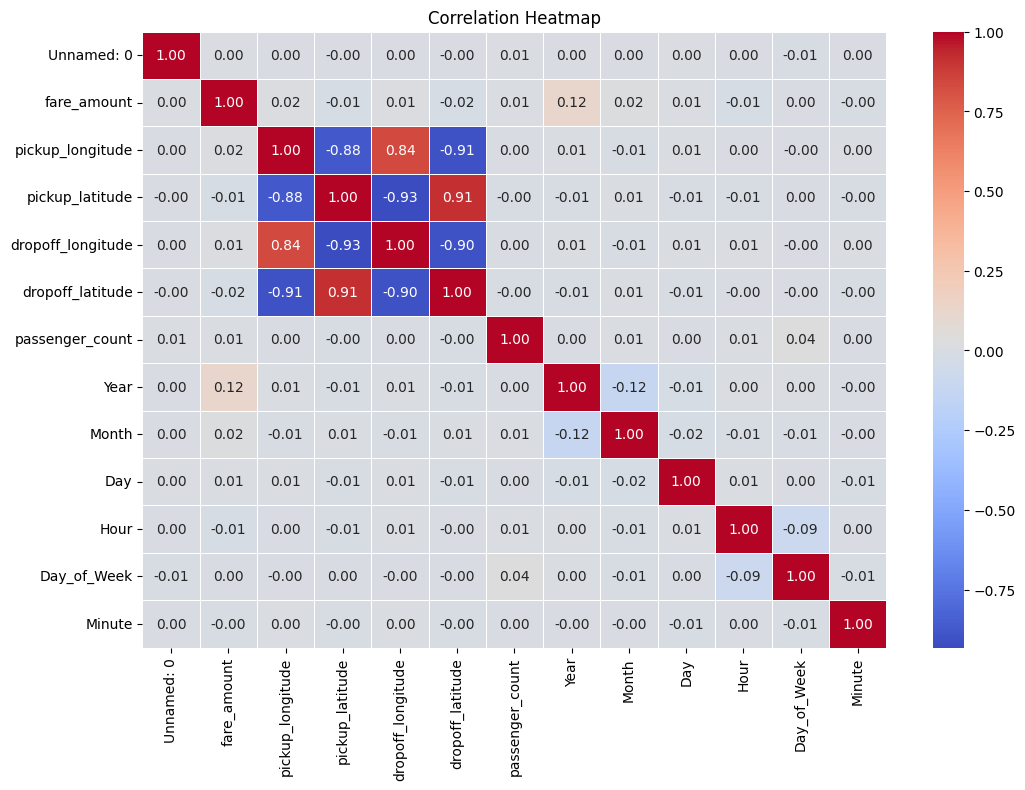

In [34]:
# Plot correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [35]:
# Correlation with fare_amount
fare_corr = correlation_matrix['fare_amount'].sort_values(ascending=False)

print(fare_corr)

fare_amount          1.000000
Year                 0.117720
Month                0.024823
pickup_longitude     0.016138
dropoff_longitude    0.012812
passenger_count      0.006489
Day                  0.005822
Unnamed: 0           0.004072
Day_of_Week          0.002265
Minute              -0.004673
Hour                -0.012902
pickup_latitude     -0.013616
dropoff_latitude    -0.017755
Name: fare_amount, dtype: float64


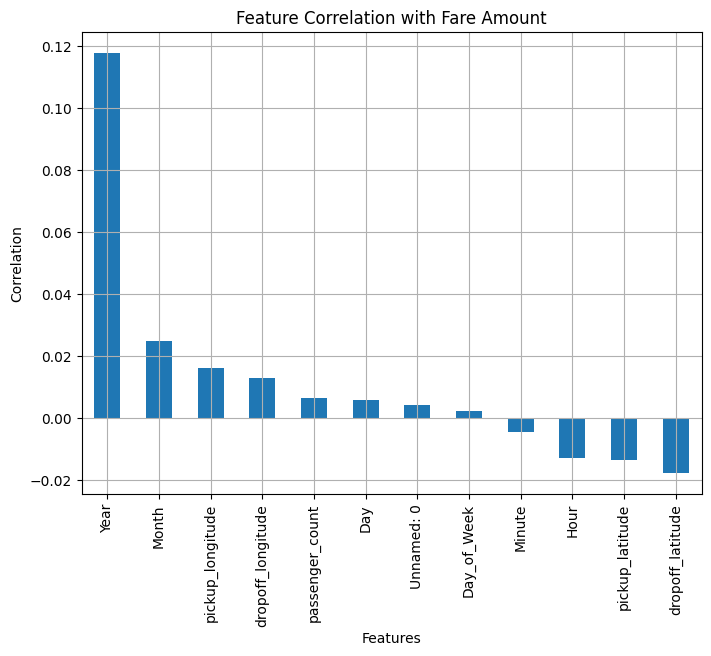

In [36]:
# Correlation with fare amount
plt.figure(figsize=(8,6))

fare_corr.drop('fare_amount').plot(kind='bar')

plt.title("Feature Correlation with Fare Amount")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.grid(True)

plt.show()

In [37]:
# Selected features
X = df[['passenger_count',
        'Year',
        'Month',
        'Day',
        'Hour',
        'Minute',
        'Day_of_Week']]

# Target variable
y = df['fare_amount']

## Step 12: Select and Train the Regression Model

In [38]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

In [39]:
# Create Linear Regression model
model = LinearRegression()

In [40]:
# Train the model
model.fit(X_train_scaled, y_train)

LinearRegression()

In [41]:
model.fit(X_train, y_train)

LinearRegression()

In [42]:
# Display coefficients
print("Coefficients:", model.coef_)

# Display intercept
print("Intercept:", model.intercept_)

Coefficients: [ 0.04543645  0.64161455  0.11400945  0.00965159 -0.0190864  -0.00262668
  0.00427813]
Intercept: -1280.0107868888379


In [43]:
# Predict fare on test data
y_pred = model.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [44]:
y_pred = model.predict(X_test)

In [45]:
# Compare actual and predicted values
results = pd.DataFrame({
    'Actual Fare': y_test,
    'Predicted Fare': y_pred
})

results.head(10)

,Actual Fare,Predicted Fare
59523,7.30,9.138787
3803,4.00,12.851584
26381,8.50,10.330585
76032,57.33,12.322398
72191,8.00,13.000200
45136,14.50,12.533733
11527,11.00,13.035256
74959,3.70,9.621208
69055,3.00,13.003462
48768,9.00,13.037808


In [46]:
print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


## Step 18: Evaluate the Regression Model

In [47]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [48]:
# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 6.0058008085091785


In [49]:
# Calculate MSE
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 100.38376908882967


In [50]:
# Calculate RMSE
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 10.019170079843423


In [51]:
# Calculate R² Score
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.017002605564732876


In [52]:
# Print all evaluation metrics
print("Model Evaluation Results")
print("-" * 35)
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Model Evaluation Results
-----------------------------------
Mean Absolute Error (MAE): 6.01
Mean Squared Error (MSE): 100.38
Root Mean Squared Error (RMSE): 10.02
R² Score: 0.017


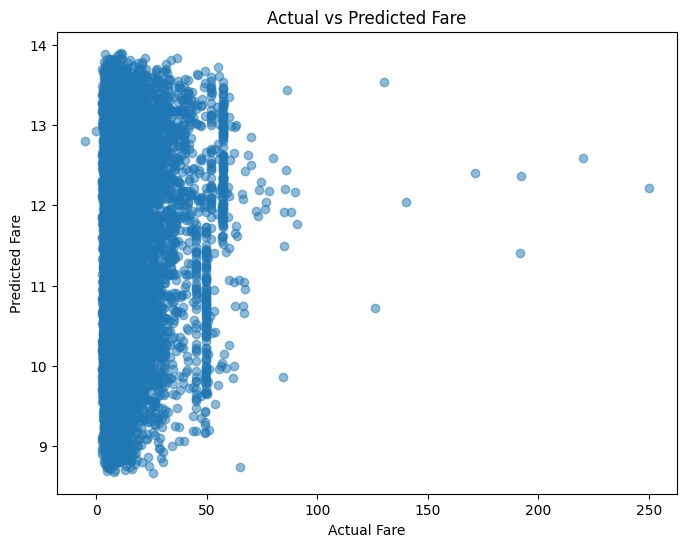

In [53]:
# Scatter plot of Actual vs Predicted Fare
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")

plt.show()

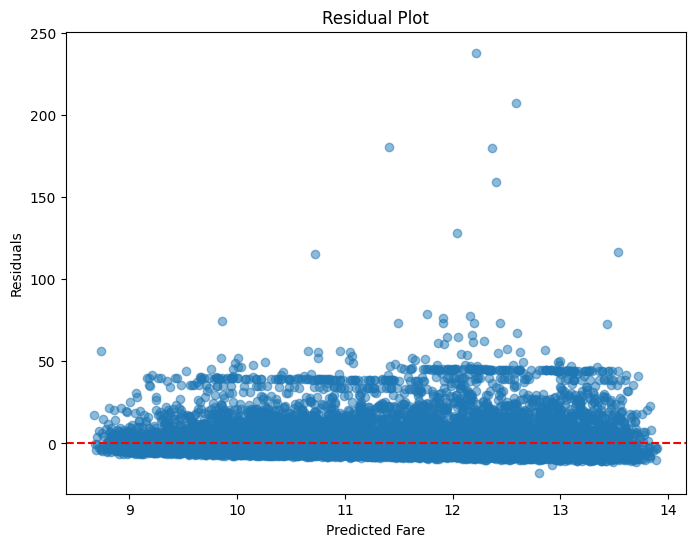

In [54]:
# Residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

## step 14 final tuning the model

In [55]:
# Import Ridge, Lasso and GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

In [56]:
# Define parameter grid
ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

# Create Ridge model
ridge = Ridge()

# Apply GridSearchCV
ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_params,
    cv=5,
    scoring='r2'
)

# Train the model
ridge_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.01, 0.1, 1, 10, 100]}, scoring='r2')

In [57]:
print("Best Ridge Parameters:")
print(ridge_grid.best_params_)

Best Ridge Parameters:
{'alpha': 100}


In [58]:
best_ridge = ridge_grid.best_estimator_

print(best_ridge)

Ridge(alpha=100)


In [59]:
# Make predictions
ridge_pred = best_ridge.predict(X_test_scaled)

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, ridge_pred))
print("MSE :", mean_squared_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2 Score:", r2_score(y_test, ridge_pred))

MAE : 6.00580488856403
MSE : 100.38413777008618
RMSE: 10.019188478618725
R2 Score: 0.016998995292695662


In [61]:
lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

In [62]:
lasso = Lasso()

lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=lasso_params,
    cv=5,
    scoring='r2'
)

lasso_grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10]}, scoring='r2')

In [63]:
print("Best Lasso Parameters:")
print(lasso_grid.best_params_)

Best Lasso Parameters:
{'alpha': 0.01}


In [64]:
best_lasso = lasso_grid.best_estimator_

lasso_pred = best_lasso.predict(X_test_scaled)

print("MAE :", mean_absolute_error(y_test, lasso_pred))
print("MSE :", mean_squared_error(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R2 Score:", r2_score(y_test, lasso_pred))

MAE : 6.006161698730391
MSE : 100.38602358144652
RMSE: 10.019282588162016
R2 Score: 0.01698052868529054


In [65]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})

print(comparison)

               Model  R2 Score
0  Linear Regression  0.017003
1   Ridge Regression  0.016999
2   Lasso Regression  0.016981


##**Evaluate Model Performance**

Calculate Performance Metrics

In [66]:
# Import required libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

Evaluate Linear Regression

In [67]:
# Calculate Linear Regression metrics
linear_mae = mean_absolute_error(y_test, y_pred)
linear_mse = mean_squared_error(y_test, y_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred)

print("Linear Regression")
print("-------------------------")
print("MAE  :", linear_mae)
print("MSE  :", linear_mse)
print("RMSE :", linear_rmse)
print("R2   :", linear_r2)

Linear Regression
-------------------------
MAE  : 6.0058008085091785
MSE  : 100.38376908882967
RMSE : 10.019170079843423
R2   : 0.017002605564732876


Evaluate Ridge Regression

In [68]:
# Calculate Ridge Regression metrics
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("-------------------------")
print("MAE  :", ridge_mae)
print("MSE  :", ridge_mse)
print("RMSE :", ridge_rmse)
print("R2   :", ridge_r2)

Ridge Regression
-------------------------
MAE  : 6.00580488856403
MSE  : 100.38413777008618
RMSE : 10.019188478618725
R2   : 0.016998995292695662


Evaluate Lasso Regression

In [70]:
# Calculate Lasso Regression metrics
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression")
print("-------------------------")
print("MAE  :", lasso_mae)
print("MSE  :", lasso_mse)
print("RMSE :", lasso_rmse)
print("R2   :", lasso_r2)

Lasso Regression
-------------------------
MAE  : 6.006161698730391
MSE  : 100.38602358144652
RMSE : 10.019282588162016
R2   : 0.01698052868529054


Create Model Comparison Table

In [71]:
# Compare all models
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression'
    ],

    'MAE': [
        linear_mae,
        ridge_mae,
        lasso_mae
    ],

    'MSE': [
        linear_mse,
        ridge_mse,
        lasso_mse
    ],

    'RMSE': [
        linear_rmse,
        ridge_rmse,
        lasso_rmse
    ],

    'R2 Score': [
        linear_r2,
        ridge_r2,
        lasso_r2
    ]
})

model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,6.005801,100.383769,10.019170,0.017003
1,Ridge Regression,6.005805,100.384138,10.019188,0.016999
2,Lasso Regression,6.006162,100.386024,10.019283,0.016981


Round the Results

In [72]:
# Round numerical values
model_comparison.round(4)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,6.0058,100.3838,10.0192,0.017
1,Ridge Regression,6.0058,100.3841,10.0192,0.017
2,Lasso Regression,6.0062,100.3860,10.0193,0.017


In [73]:
# Find the model with the highest R2 score
best_model_name = model_comparison.loc[
    model_comparison['R2 Score'].idxmax(),
    'Model'
]

print("Best Model:", best_model_name)

Best Model: Linear Regression


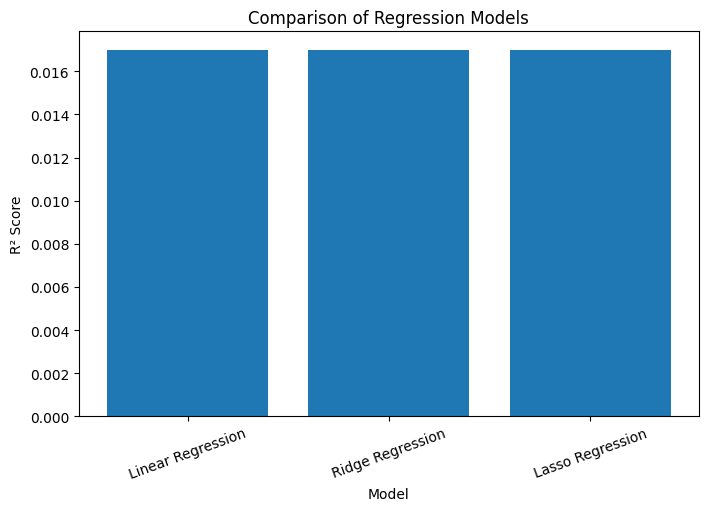

In [74]:
# Plot R2 scores
plt.figure(figsize=(8,5))

plt.bar(
    model_comparison['Model'],
    model_comparison['R2 Score']
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Comparison of Regression Models")

plt.xticks(rotation=20)
plt.show()

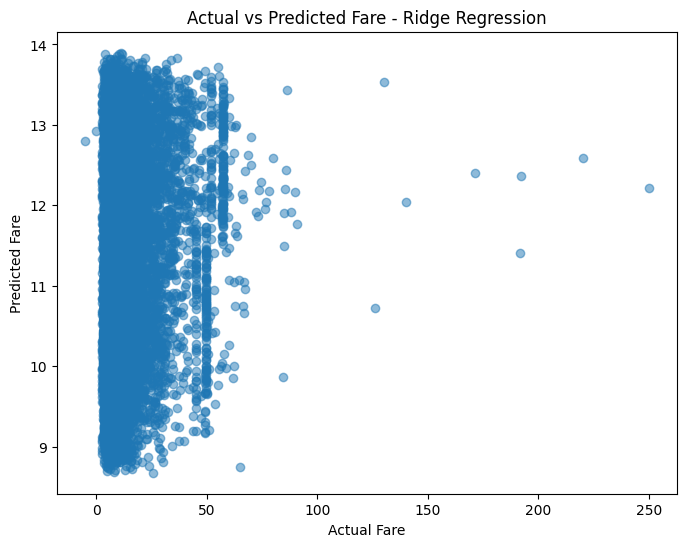

In [75]:
# Actual vs Predicted values for Ridge Regression
plt.figure(figsize=(8,6))

plt.scatter(y_test, ridge_pred, alpha=0.5)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare - Ridge Regression")

plt.show()

In [76]:
final_model = model

print("Final model selected: Linear Regression")

Final model selected: Linear Regression
